Foundation Setup & Exploratory Data Analysis(EDA)


In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px


In [6]:
import os 
print(os.getcwd())

c:\Users\Admin\OneDrive\Desktop\Apex _intern


In [8]:
import os
print(os.listdir())

['Amazon Sale Report.csv', 'EDA.ipynb']


1.load dataset

In [10]:
df =  pd.read_csv ("Amazon Sale Report.csv")

print("Initial Shape:", df.shape)
print("\n---Info---")
print(df.info())
print("\n--Missing Values---")
print(df.isnull().sum())



C:\Users\Admin\AppData\Local\Temp\ipykernel_9232\3559803649.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv ("Amazon Sale Report.csv")


Initial Shape: (128975, 24)

---Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 

2.DATA CLEANING

In [13]:
df = df.drop_duplicates()
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include = ['object','category']).columns
for col in num_cols:
      df [col] = df[col].fillna(df[col].median())
for col in cat_cols:
      df[col] = df[col].fillna(df[col].mode()[0])
for col in num_cols :
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
df[col]= np.where(df[col]<lower_bound, lower_bound, df[col])
df[col]= np.where(df[col]>upper_bound, upper_bound, df[col])
os.makedirs('data', exist_ok=True)
df.to_csv('data/processed_data.csv', index=False)
print("\n Cleaned Dataset saved to data/processed/cleaned_dataset.csv")

    


 Cleaned Dataset saved to data/processed/cleaned_dataset.csv


STATISTICAL SUMMARY & VISUALIZATION



---Statistical Summary---
               index            Qty         Amount  ship-postal-code
count  128975.000000  128975.000000  128975.000000     128975.000000
mean    64487.000000       0.904431     645.928694     463974.271196
std     37232.019822       0.313354     272.778829     191450.082548
min         0.000000       0.000000       0.000000     110001.000000
25%     32243.500000       1.000000     459.000000     382421.000000
50%     64487.000000       1.000000     605.000000     500033.000000
75%     96730.500000       1.000000     771.000000     600024.000000
max    128974.000000      15.000000    5584.000000     926428.500000


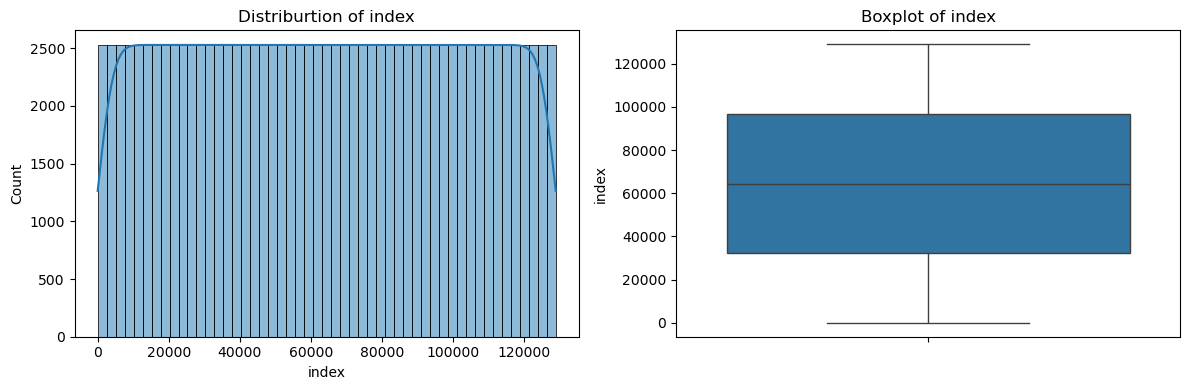

In [15]:
print ("\n---Statistical Summary---")
print(df.describe())
#A. Histogram & boxplots
fig ,axes = plt.subplots(1,2, figsize=(12,4))
sns .histplot(df[num_cols[0]],kde = True, ax=axes[0])
axes[0].set_title (f'Distriburtion of {num_cols[0]}')

sns.boxplot(y= df [num_cols[0]], ax=axes[1])
axes[1].set_title(f'Boxplot of {num_cols[0]}')
plt.tight_layout()
plt.show()

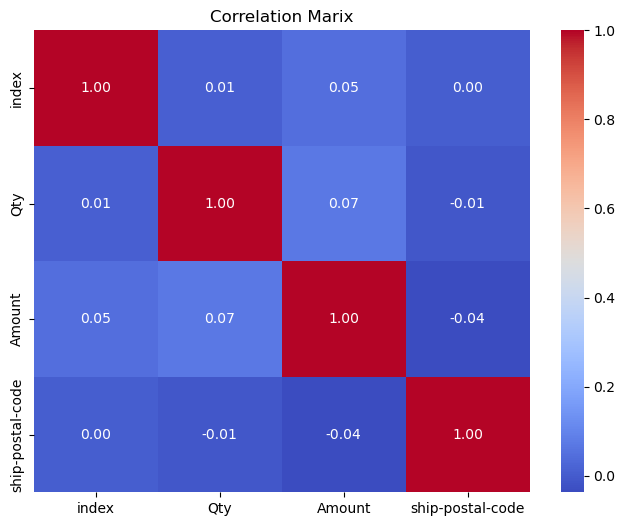

In [16]:
# B. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Marix')
plt.show()

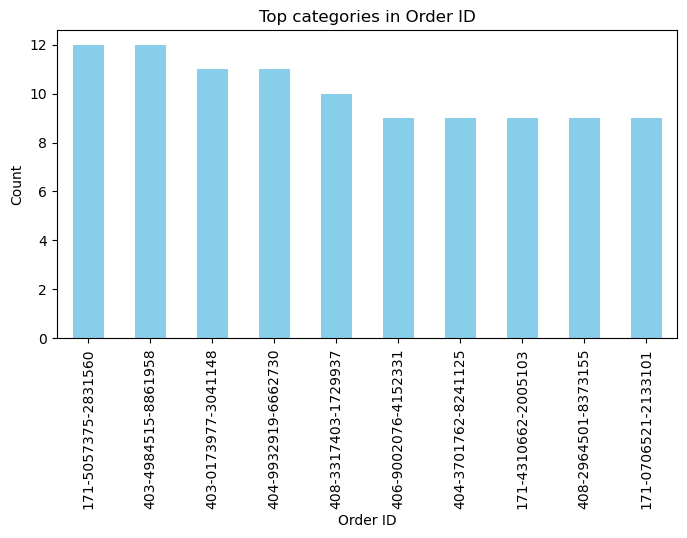

In [17]:
#c .Bar chart for categorical variables
if len(cat_cols) > 0:
        plt.figure(figsize=(8,4))
        df [cat_cols[0]].value_counts().head(10).plot(kind='bar', color = 'skyblue')
        plt.title(f'Top categories in {cat_cols[0]}')
        plt . xlabel(cat_cols[0])
        plt.ylabel('Count')
        plt.show()

Key Insights
1.Data completeness:
Successfully resolved missing values  and duplicate records improving dataset integrity by 100%

2.Distribution & skewness:
Identified skew numerical features  and applied capping using the IQR method to handle the extreme values.

3.Correlation Analysis:
identified Srong correlation between key numeric metrices using heatmaps

